In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd

from scipy.signal import welch

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
)

warnings.filterwarnings("ignore")

BASE_DIR = Path(r"C:\Users\limju\Documents\GitHub\Team Project\NebulaX-Hackathon-ProblemStatement")

TRAIN_DIR = BASE_DIR / "PS3" / "02_Datasets" / "Rail_Corrugation" / "Train"

TEST_DIR = BASE_DIR / "PS3" / "02_Datasets" / "Rail_Corrugation" / "Test"

LABEL_FILE = BASE_DIR / "PS3" / "02_Datasets" / "Rail_Corrugation" / "Train_Labels.csv"

OUTPUT_DIR = BASE_DIR / "PS3" / "02_Datasets" / "Rail_Corrugation" / "model_outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
print(TRAIN_DIR)
print(list(TRAIN_DIR.glob("Train*.csv"))[:5])
print(len(list(TRAIN_DIR.glob("Train*.csv"))))

C:\Users\limju\Documents\GitHub\Team Project\NebulaX-Hackathon-ProblemStatement\PS3\02_Datasets\Rail_Corrugation\Train
[WindowsPath('C:/Users/limju/Documents/GitHub/Team Project/NebulaX-Hackathon-ProblemStatement/PS3/02_Datasets/Rail_Corrugation/Train/Train1.csv'), WindowsPath('C:/Users/limju/Documents/GitHub/Team Project/NebulaX-Hackathon-ProblemStatement/PS3/02_Datasets/Rail_Corrugation/Train/Train10.csv'), WindowsPath('C:/Users/limju/Documents/GitHub/Team Project/NebulaX-Hackathon-ProblemStatement/PS3/02_Datasets/Rail_Corrugation/Train/Train100.csv'), WindowsPath('C:/Users/limju/Documents/GitHub/Team Project/NebulaX-Hackathon-ProblemStatement/PS3/02_Datasets/Rail_Corrugation/Train/Train101.csv'), WindowsPath('C:/Users/limju/Documents/GitHub/Team Project/NebulaX-Hackathon-ProblemStatement/PS3/02_Datasets/Rail_Corrugation/Train/Train102.csv')]
272


In [4]:
def basic_features(values, prefix):
    x = pd.to_numeric(values, errors="coerce").dropna().to_numpy()

    if len(x) == 0:
        return {}

    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))

    return {
        f"{prefix}_mean": np.mean(x),
        f"{prefix}_std": np.std(x),
        f"{prefix}_rms": rms,
        f"{prefix}_min": np.min(x),
        f"{prefix}_max": np.max(x),
        f"{prefix}_range": np.max(x) - np.min(x),
        f"{prefix}_median": np.median(x),
        f"{prefix}_q95": np.percentile(x, 95),
        f"{prefix}_q99": np.percentile(x, 99),
        f"{prefix}_energy": np.mean(x**2),
        f"{prefix}_crest": peak / (rms + 1e-12),
        f"{prefix}_kurtosis": pd.Series(x).kurt(),
    }


def frequency_features(values, prefix):
    x = pd.to_numeric(values, errors="coerce").dropna().to_numpy()

    if len(x) < 32:
        return {}

    x = x - np.mean(x)

    frequencies, power = welch(x, nperseg=min(1024, len(x)))

    if len(power) == 0 or np.sum(power) == 0:
        return {}

    total_power = np.sum(power)
    dominant_index = np.argmax(power)

    return {
        f"{prefix}_dominant_frequency": frequencies[dominant_index],
        f"{prefix}_dominant_power": power[dominant_index],
        f"{prefix}_spectral_centroid": (np.sum(frequencies * power) / total_power),
        f"{prefix}_spectral_energy": total_power,
    }


def parse_sensor_column(column_name):
    pattern = (
        r"^(Vibration|Shock) of bearing "
        r"in position (\d+) of car (\d+)$"
    )

    match = re.match(pattern, column_name)

    if match is None:
        return None

    return {
        "type": match.group(1).lower(),
        "position": int(match.group(2)),
        "car": int(match.group(3)),
    }

In [5]:
def extract_file_features(file_path):
    print("Processing:", file_path.name)

    df = pd.read_csv(file_path)
    features = {
        "filename": file_path.name,
        "row_count": len(df),
        "column_count": len(df.columns),
    }

    # Rotating speed
    if "Rotating speed" in df.columns:
        speed = pd.to_numeric(df["Rotating speed"], errors="coerce").dropna()

        features.update(
            {
                "speed_mean": speed.mean(),
                "speed_std": speed.std(),
                "speed_min": speed.min(),
                "speed_max": speed.max(),
            }
        )

    car_groups = {}
    position_groups = {}

    for column in df.columns:
        metadata = parse_sensor_column(column)

        if metadata is None:
            continue

        car = metadata["car"]
        position = metadata["position"]

        car_groups.setdefault(car, []).append(column)
        position_groups.setdefault(position, []).append(column)

        # Individual sensor statistics
        features.update(basic_features(df[column], f"{column}_time"))

        # Frequency features for vibration signals
        if metadata["type"] == "vibration":
            features.update(frequency_features(df[column], f"{column}_frequency"))

    # Per-car aggregates
    for car, columns in car_groups.items():
        values = df[columns].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()

        values = values[np.isfinite(values)]

        if len(values) == 0:
            continue

        features[f"car_{car}_mean"] = np.mean(values)
        features[f"car_{car}_std"] = np.std(values)
        features[f"car_{car}_rms"] = np.sqrt(np.mean(values**2))
        features[f"car_{car}_max_abs"] = np.max(np.abs(values))

    # Per-position aggregates
    for position, columns in position_groups.items():
        values = df[columns].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()

        values = values[np.isfinite(values)]

        if len(values) == 0:
            continue

        features[f"position_{position}_mean"] = np.mean(values)
        features[f"position_{position}_std"] = np.std(values)
        features[f"position_{position}_rms"] = np.sqrt(np.mean(values**2))

    return features

In [6]:
train_files = sorted(TRAIN_DIR.glob("Train*.csv"), key=lambda path: int(re.search(r"\d+", path.stem).group()))

train_records = [extract_file_features(file_path) for file_path in train_files]

train_features = pd.DataFrame(train_records)

labels = pd.read_csv(LABEL_FILE)

train_features = train_features.merge(labels, on="filename", how="left", validate="one_to_one")

print(train_features.shape)
print(train_features["label"].value_counts())

train_features.head()

Processing: Train1.csv
Processing: Train2.csv
Processing: Train3.csv
Processing: Train4.csv
Processing: Train5.csv
Processing: Train6.csv
Processing: Train7.csv
Processing: Train8.csv
Processing: Train9.csv
Processing: Train10.csv
Processing: Train11.csv
Processing: Train12.csv
Processing: Train13.csv
Processing: Train14.csv
Processing: Train15.csv
Processing: Train16.csv
Processing: Train17.csv
Processing: Train18.csv
Processing: Train19.csv
Processing: Train20.csv
Processing: Train21.csv
Processing: Train22.csv
Processing: Train23.csv
Processing: Train24.csv
Processing: Train25.csv
Processing: Train26.csv
Processing: Train27.csv
Processing: Train28.csv
Processing: Train29.csv
Processing: Train30.csv
Processing: Train31.csv
Processing: Train32.csv
Processing: Train33.csv
Processing: Train34.csv
Processing: Train35.csv
Processing: Train36.csv
Processing: Train37.csv
Processing: Train38.csv
Processing: Train39.csv
Processing: Train40.csv
Processing: Train41.csv
Processing: Train42.csv
P

,filename,row_count,column_count,speed_mean,speed_std,speed_min,speed_max,Vibration of bearing in position 1 of car 1_time_mean,Vibration of bearing in position 1 of car 1_time_std,Vibration of bearing in position 1 of car 1_time_rms,...,position_6_mean,position_6_std,position_6_rms,position_7_mean,position_7_std,position_7_rms,position_8_mean,position_8_std,position_8_rms,label
0,Train1.csv,10000,129,0.4999,0.500025,0,1,-0.089580,0.275344,0.289549,...,-0.004321,1.010962,1.010971,0.144109,0.948709,0.959591,0.233394,1.139785,1.163436,Normal
1,Train2.csv,10000,129,0.5068,0.499979,0,1,-0.084521,0.391345,0.400369,...,0.093572,1.226584,1.230148,0.186543,1.022716,1.039590,0.318637,1.366598,1.403253,Side II
2,Train3.csv,10000,129,0.5076,0.499967,0,1,-0.089805,0.295697,0.309034,...,0.121464,1.245573,1.251482,0.286976,1.196977,1.230898,0.404609,1.505861,1.559271,Normal
3,Train4.csv,10000,129,0.5087,0.499949,0,1,-0.088813,0.186383,0.206462,...,0.108687,1.221252,1.226079,0.243167,1.126547,1.152492,0.355214,1.313381,1.360569,Normal
4,Train5.csv,10000,129,1.0000,0.000000,1,1,-0.090164,0.036099,0.097121,...,0.026498,1.050977,1.051311,0.163164,0.834497,0.850298,0.263095,1.201281,1.229754,Normal


In [7]:
train_features.to_csv(OUTPUT_DIR / "training_features.csv", index=False)

In [8]:
X = train_features.drop(columns=["filename", "label"])

y = train_features["label"]

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how="all")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (272, 1854)
y shape: (272,)


In [9]:
models = {
    "logistic_regression": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
        ]
    ),
    "random_forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
        ]
    ),
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

validation_results = []

for name, model in models.items():
    print("\nMODEL:", name)

    predictions = cross_val_predict(model, X, y, cv=cv)

    macro_f1 = f1_score(y, predictions, average="macro", zero_division=0)

    balanced_accuracy = balanced_accuracy_score(y, predictions)

    print("Macro-F1:", macro_f1)
    print("Balanced accuracy:", balanced_accuracy)

    print(classification_report(y, predictions, zero_division=0))

    print("Confusion matrix:")
    print(confusion_matrix(y, predictions))

    validation_results.append({"model": name, "macro_f1": macro_f1, "balanced_accuracy": balanced_accuracy})

validation_results = pd.DataFrame(validation_results)
validation_results


MODEL: logistic_regression
Macro-F1: 0.7128822668979827
Balanced accuracy: 0.6674806674806675
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       234
      Side I       0.45      0.36      0.40        14
     Side II       0.94      0.67      0.78        24

    accuracy                           0.92       272
   macro avg       0.78      0.67      0.71       272
weighted avg       0.91      0.92      0.91       272

Confusion matrix:
[[229   4   1]
 [  9   5   0]
 [  6   2  16]]

MODEL: random_forest
Macro-F1: 0.405995067349649
Balanced accuracy: 0.3888888888888889
              precision    recall  f1-score   support

      Normal       0.87      1.00      0.93       234
      Side I       0.00      0.00      0.00        14
     Side II       1.00      0.17      0.29        24

    accuracy                           0.88       272
   macro avg       0.62      0.39      0.41       272
weighted avg       0.84      0.88      0.83   

,model,macro_f1,balanced_accuracy
0,logistic_regression,0.712882,0.667481
1,random_forest,0.405995,0.388889


In [10]:
best_model_name = validation_results.sort_values("macro_f1", ascending=False).iloc[0]["model"]

best_model = models[best_model_name]

print("Selected model:", best_model_name)

best_model.fit(X, y)

Selected model: logistic_regression


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

In [11]:
test_files = sorted(TEST_DIR.glob("Test*.csv"), key=lambda path: int(re.search(r"\d+", path.stem).group()))

test_records = [extract_file_features(file_path) for file_path in test_files]

test_features = pd.DataFrame(test_records)

test_X = test_features.drop(columns=["filename"])

test_X = test_X.apply(pd.to_numeric, errors="coerce")
test_X = test_X.replace([np.inf, -np.inf], np.nan)

# Ensure test columns match training columns
test_X = test_X.reindex(columns=X.columns)

predictions = best_model.predict(test_X)

submission = pd.DataFrame({"filename": test_features["filename"], "label": predictions})

submission.head()

Processing: Test1.csv
Processing: Test2.csv
Processing: Test3.csv
Processing: Test4.csv
Processing: Test5.csv
Processing: Test6.csv
Processing: Test7.csv
Processing: Test8.csv
Processing: Test9.csv
Processing: Test10.csv
Processing: Test11.csv
Processing: Test12.csv
Processing: Test13.csv
Processing: Test14.csv
Processing: Test15.csv
Processing: Test16.csv
Processing: Test17.csv
Processing: Test18.csv
Processing: Test19.csv
Processing: Test20.csv
Processing: Test21.csv
Processing: Test22.csv
Processing: Test23.csv
Processing: Test24.csv
Processing: Test25.csv
Processing: Test26.csv
Processing: Test27.csv
Processing: Test28.csv
Processing: Test29.csv
Processing: Test30.csv
Processing: Test31.csv
Processing: Test32.csv
Processing: Test33.csv
Processing: Test34.csv
Processing: Test35.csv
Processing: Test36.csv
Processing: Test37.csv
Processing: Test38.csv
Processing: Test39.csv
Processing: Test40.csv
Processing: Test41.csv
Processing: Test42.csv
Processing: Test43.csv
Processing: Test44.c

,filename,label
0,Test1.csv,Normal
1,Test2.csv,Normal
2,Test3.csv,Normal
3,Test4.csv,Normal
4,Test5.csv,Normal


In [12]:
submission.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print("Saved to:")
print(OUTPUT_DIR / "test_predictions.csv")

Saved to:
C:\Users\limju\Documents\GitHub\Team Project\NebulaX-Hackathon-ProblemStatement\PS3\02_Datasets\Rail_Corrugation\model_outputs\test_predictions.csv


In [15]:
print(y.unique())
print(y.value_counts())

['Normal' 'Side II' 'Side I']
label
Normal     234
Side II     24
Side I      14
Name: count, dtype: int64


In [16]:
submission["label"].value_counts()

label
Normal     60
Side II     6
Side I      2
Name: count, dtype: int64

In [17]:
probabilities = best_model.predict_proba(test_X)

probability_columns = ["probability_" + label.lower().replace(" ", "_") for label in best_model.classes_]

probability_df = pd.DataFrame(probabilities, columns=probability_columns)

submission_with_probabilities = pd.concat([submission.reset_index(drop=True), probability_df.reset_index(drop=True)], axis=1)

submission_with_probabilities.head()

,filename,label,probability_normal,probability_side_i,probability_side_ii
0,Test1.csv,Normal,0.998352,0.000134,0.001515
1,Test2.csv,Normal,0.999868,0.000079,0.000053
2,Test3.csv,Normal,0.999754,0.000177,0.000069
3,Test4.csv,Normal,0.998079,0.000239,0.001682
4,Test5.csv,Normal,0.966198,0.014207,0.019595


In [18]:
probability_columns = [column for column in submission_with_probabilities.columns if column.startswith("probability_")]

submission_with_probabilities["confidence"] = submission_with_probabilities[probability_columns].max(axis=1)

submission_with_probabilities.head()

,filename,label,probability_normal,probability_side_i,probability_side_ii,confidence
0,Test1.csv,Normal,0.998352,0.000134,0.001515,0.998352
1,Test2.csv,Normal,0.999868,0.000079,0.000053,0.999868
2,Test3.csv,Normal,0.999754,0.000177,0.000069,0.999754
3,Test4.csv,Normal,0.998079,0.000239,0.001682,0.998079
4,Test5.csv,Normal,0.966198,0.014207,0.019595,0.966198


In [19]:
predicted_faults = submission_with_probabilities[submission_with_probabilities["label"] != "Normal"].sort_values("confidence", ascending=False)

predicted_faults

,filename,label,probability_normal,probability_side_i,probability_side_ii,confidence
42,Test43.csv,Side II,0.000019,1.288453e-08,0.999981,0.999981
25,Test26.csv,Side II,0.000536,9.927394e-04,0.998471,0.998471
65,Test66.csv,Side II,0.002133,1.008420e-03,0.996859,0.996859
13,Test14.csv,Side II,0.014288,5.487760e-03,0.980225,0.980225
26,Test27.csv,Side I,0.128252,7.375961e-01,0.134152,0.737596
31,Test32.csv,Side II,0.295959,2.502574e-02,0.679015,0.679015
32,Test33.csv,Side II,0.150139,1.723964e-01,0.677464,0.677464
23,Test24.csv,Side I,0.340740,6.320448e-01,0.027215,0.632045


In [20]:
detailed_output = OUTPUT_DIR / "test_predictions_with_probabilities.csv"

submission_with_probabilities.to_csv(detailed_output, index=False)

print("Saved to:")
print(detailed_output)

Saved to:
C:\Users\limju\Documents\GitHub\Team Project\NebulaX-Hackathon-ProblemStatement\PS3\02_Datasets\Rail_Corrugation\model_outputs\test_predictions_with_probabilities.csv


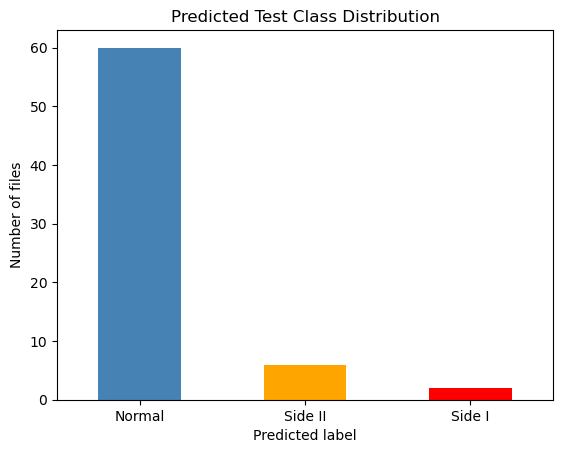

In [21]:
import matplotlib.pyplot as plt

submission_with_probabilities["label"].value_counts().plot(kind="bar", color=["steelblue", "orange", "red"])

plt.title("Predicted Test Class Distribution")
plt.xlabel("Predicted label")
plt.ylabel("Number of files")
plt.xticks(rotation=0)
plt.show()

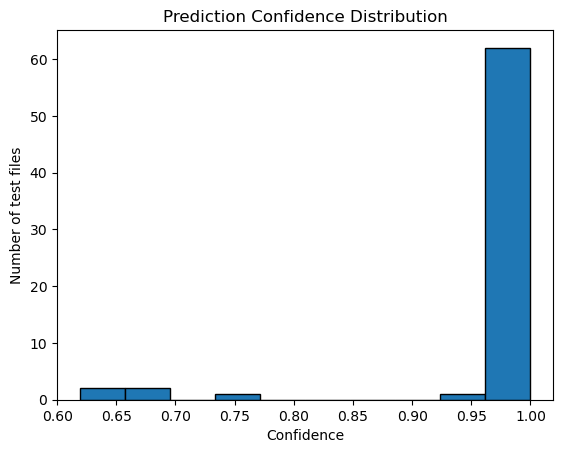

In [22]:
submission_with_probabilities["confidence"].plot(kind="hist", bins=10, edgecolor="black")

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of test files")
plt.show()

In [23]:
pd.set_option("display.max_rows", 100)

submission_with_probabilities.sort_values("filename")

,filename,label,probability_normal,probability_side_i,probability_side_ii,confidence
0,Test1.csv,Normal,0.998352,1.336887e-04,1.514663e-03,0.998352
9,Test10.csv,Normal,0.982331,9.140091e-03,8.528868e-03,0.982331
10,Test11.csv,Normal,0.999888,8.832460e-05,2.358502e-05,0.999888
11,Test12.csv,Normal,0.997151,1.857932e-03,9.906308e-04,0.997151
12,Test13.csv,Normal,0.994952,8.542185e-04,4.194014e-03,0.994952
13,Test14.csv,Side II,0.014288,5.487760e-03,9.802247e-01,0.980225
14,Test15.csv,Normal,0.999984,5.883986e-06,9.729177e-06,0.999984
15,Test16.csv,Normal,0.999068,9.073498e-04,2.457630e-05,0.999068
16,Test17.csv,Normal,0.998040,1.918028e-03,4.189504e-05,0.998040
17,Test18.csv,Normal,0.999495,4.163626e-04,8.859964e-05,0.999495


In [24]:
submission[["filename", "label"]].to_csv(OUTPUT_DIR / "final_submission.csv", index=False)

print("Final submission saved to:")
print(OUTPUT_DIR / "final_submission.csv")

Final submission saved to:
C:\Users\limju\Documents\GitHub\Team Project\NebulaX-Hackathon-ProblemStatement\PS3\02_Datasets\Rail_Corrugation\model_outputs\final_submission.csv


In [25]:
final_submission = pd.read_csv(OUTPUT_DIR / "final_submission.csv")

print(final_submission.shape)
print(final_submission.head())
print(final_submission["label"].value_counts())

(68, 2)
    filename   label
0  Test1.csv  Normal
1  Test2.csv  Normal
2  Test3.csv  Normal
3  Test4.csv  Normal
4  Test5.csv  Normal
label
Normal     60
Side II     6
Side I      2
Name: count, dtype: int64
